# Una onda sísmica fue hasta el núcleo de la Tierra, volvió, y movió Japón entero

El 11 de marzo de 2011, el terremoto de Tohoku-Oki (magnitud 9,0) lanzó una onda de corte tan fuerte que bajó hasta el núcleo de la Tierra, rebotó y regresó a la superficie. Cuando esa onda —llamada **ScS**— reapareció en Japón, los GPS de todo el país registraron un **escalón hacia el este de hasta 5 a 6 milímetros**: el suelo se desplazó y se quedó ahí. Los autores lo atribuyen a que la onda, al llegar casi al mismo tiempo a todo el archipiélago, disparó pequeños deslizamientos en las fallas bajo Japón.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *ScS-triggered slip on megathrust interfaces after the 2011 Mw 9.0 Tohoku-Oki earthquake* — *Science* (2026).
**DOI:** [10.1126/science.aec4190](https://doi.org/10.1126/science.aec4190)
**Datos:** series sintéticas de desplazamiento en estaciones GNSS GEONET vía [Zenodo](https://doi.org/10.5281/zenodo.19597316).

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-18-scs-tohoku-megathrust-slip/notebook.ipynb)

**Video:** [Pendiente]

## Qué estamos mirando

Una onda **ScS** es una onda de corte (la "S" de los sismos) que viaja hacia abajo, rebota en el límite con el núcleo externo de la Tierra —a unos 2.900 km de profundidad— y vuelve a subir. El terremoto de Tohoku fue tan grande que su ScS llegó a la superficie con fuerza suficiente para sacudir Japón una segunda vez, varios minutos después de la ruptura.

El dataset que abrimos son series **sintéticas** (simuladas por el modelo de los autores) de cómo se movió el suelo hacia el este en **1.221 estaciones GNSS** repartidas por todo Japón, desde Okinawa hasta Hokkaido. El dato observado real ronda los 5 a 6 mm; veamos cuánto reproduce el modelo y, sobre todo, qué forma tiene el movimiento.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ESTACION_HERO = '0550'        # estación más cercana a la ruptura con paso grande
UMBRAL_SENAL  = 1.0           # mm — a partir de aquí consideramos que hubo escalón
COLOR_DATOS      = '#2563EB'  # azul CaM — el desplazamiento sintético
COLOR_ALERTA     = '#DC2626'  # rojo — el escalón / el epicentro
COLOR_REFERENCIA = '#D97706'  # ámbar — umbrales
COLOR_CONTEXTO   = '#BBBBBB'  # gris — estaciones sin señal
FUENTE = 'Fuente: Science (2026), DOI 10.1126/science.aec4190 | Datos sintéticos: GEONET via Zenodo'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local -> /tmp -> GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga
estaciones = pd.read_csv('datos/step_por_estacion.csv', dtype={'station': str})
serie      = pd.read_csv('datos/timeseries_0550.csv')
bandas     = pd.read_csv('datos/step_por_distancia.csv')

n_total   = len(estaciones)
n_senal   = int((estaciones.step_mm >= UMBRAL_SENAL).sum())
pct_senal = 100 * n_senal / n_total
hero      = estaciones[estaciones.station == ESTACION_HERO].iloc[0]

print(f"Estaciones GNSS en el dataset : {n_total:,}".replace(',', '.'))
print(f"Con escalón >= {UMBRAL_SENAL:.0f} mm        : {n_senal} ({pct_senal:.1f} %)")
print(f"Escalón máximo (sintético)    : {estaciones.step_mm.max():.2f} mm (estación {ESTACION_HERO})")
print(f"Escalón mediano               : {estaciones.step_mm.median():.3f} mm")
print(f"Estación {ESTACION_HERO}: {hero.dist_km:.0f} km del epicentro, costa de Sanriku")

Estaciones GNSS en el dataset : 1.221
Con escalón >= 1 mm        : 104 (8.5 %)
Escalón máximo (sintético)    : 4.79 mm (estación 0550)
Escalón mediano               : 0.059 mm
Estación 0550: 214 km del epicentro, costa de Sanriku


Veamos primero una sola estación, la más golpeada. Aquí está.

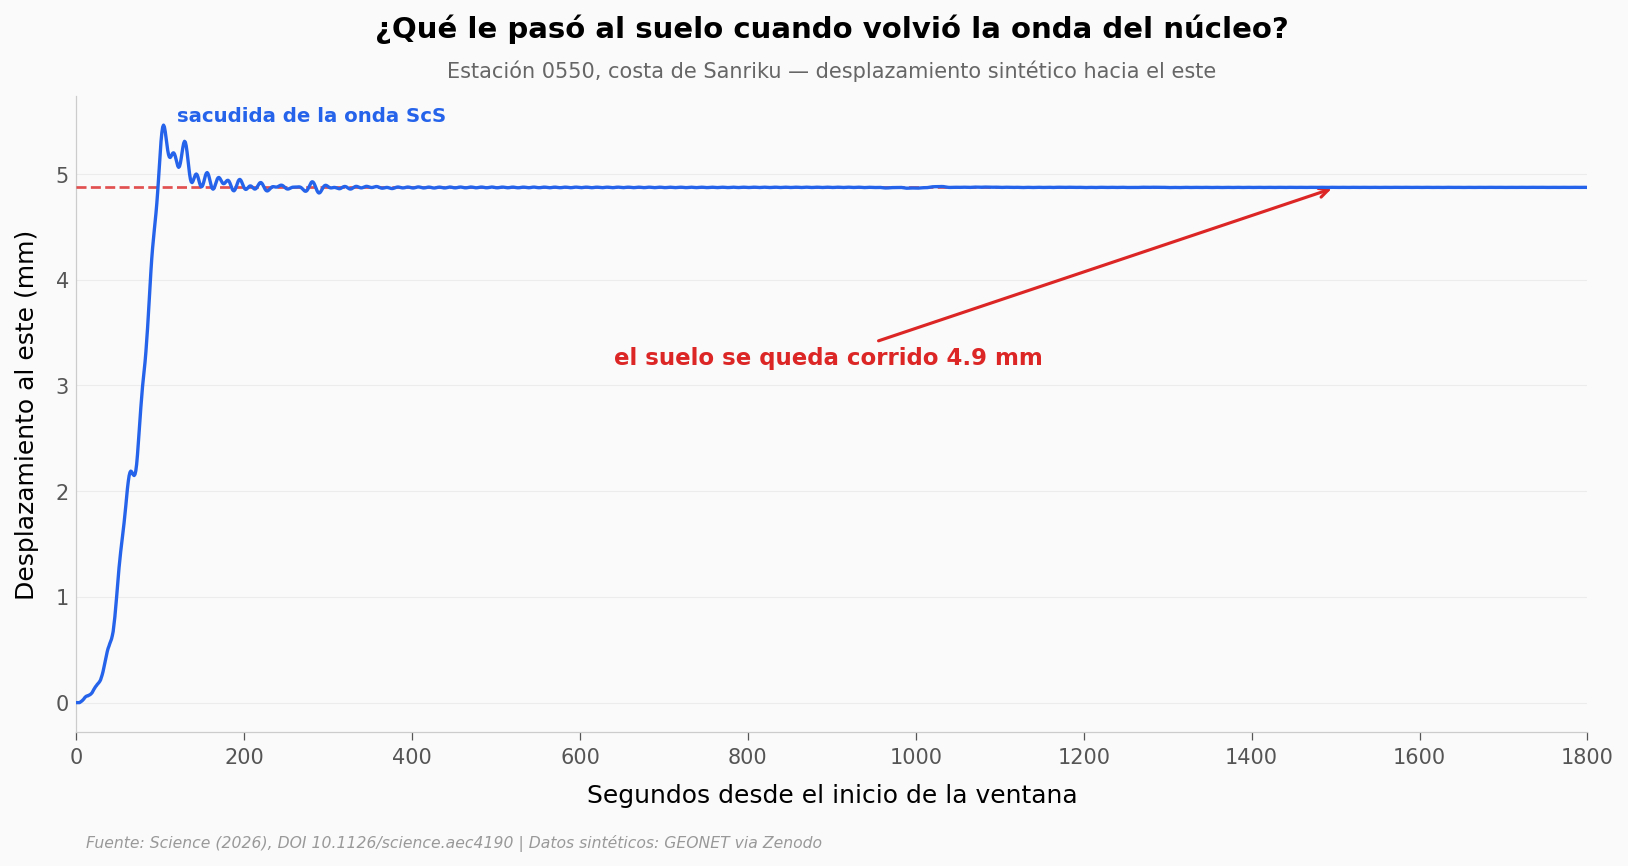

Pico de la sacudida ScS : 5.46 mm
Escalón permanente      : 4.87 mm


In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(serie.time_s, serie.disp_mm, color=COLOR_DATOS, linewidth=1.6, zorder=4)

# Nivel permanente al que se queda el suelo (promedio de la última parte de la ventana)
paso_final = serie.disp_mm.iloc[-600:].mean()
ax.axhline(y=paso_final, color=COLOR_ALERTA, linewidth=1.3, linestyle='--', alpha=0.8, zorder=3)
ax.annotate(f'el suelo se queda corrido {paso_final:.1f} mm',
            xy=(1500, paso_final), xytext=(640, 3.2),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.text(120, 5.5, 'sacudida de la onda ScS', fontsize=9.5,
        color=COLOR_DATOS, fontweight='bold', ha='left')

ax.set_title('¿Qué le pasó al suelo cuando volvió la onda del núcleo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Estación {ESTACION_HERO}, costa de Sanriku — desplazamiento sintético hacia el este',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Segundos desde el inicio de la ventana')
ax.set_ylabel('Desplazamiento al este (mm)')
ax.set_xlim(0, 1800)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/serie_hero.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Pico de la sacudida ScS : {serie.disp_mm.max():.2f} mm")
print(f"Escalón permanente      : {paso_final:.2f} mm")

Pasan unos segundos en calma y, de golpe, el suelo salta: la onda ScS llega y sacude la estación hasta más de 5 mm. Pero lo interesante no es la sacudida —eso es una onda que pasa—, sino lo que queda **después**. El suelo no vuelve a cero: se estabiliza unos 4,8 mm más al este de donde estaba. Esa diferencia permanente es el "escalón", la huella de que algo cedió allá abajo y no se devolvió.

Ojo con la escala de certeza: este trazo es **sintético**, una realización del modelo de los autores. En los GPS reales el escalón observado llega a 5 a 6 mm —el modelo se queda un pelín corto, como suele pasar.

Una estación es una anécdota. La pregunta de verdad es: ¿le pasó esto a todo Japón, o solo a un punto cerca de la ruptura? Pongamos las 1.221 estaciones en el mapa, cada una pintada según cuánto se corrió.

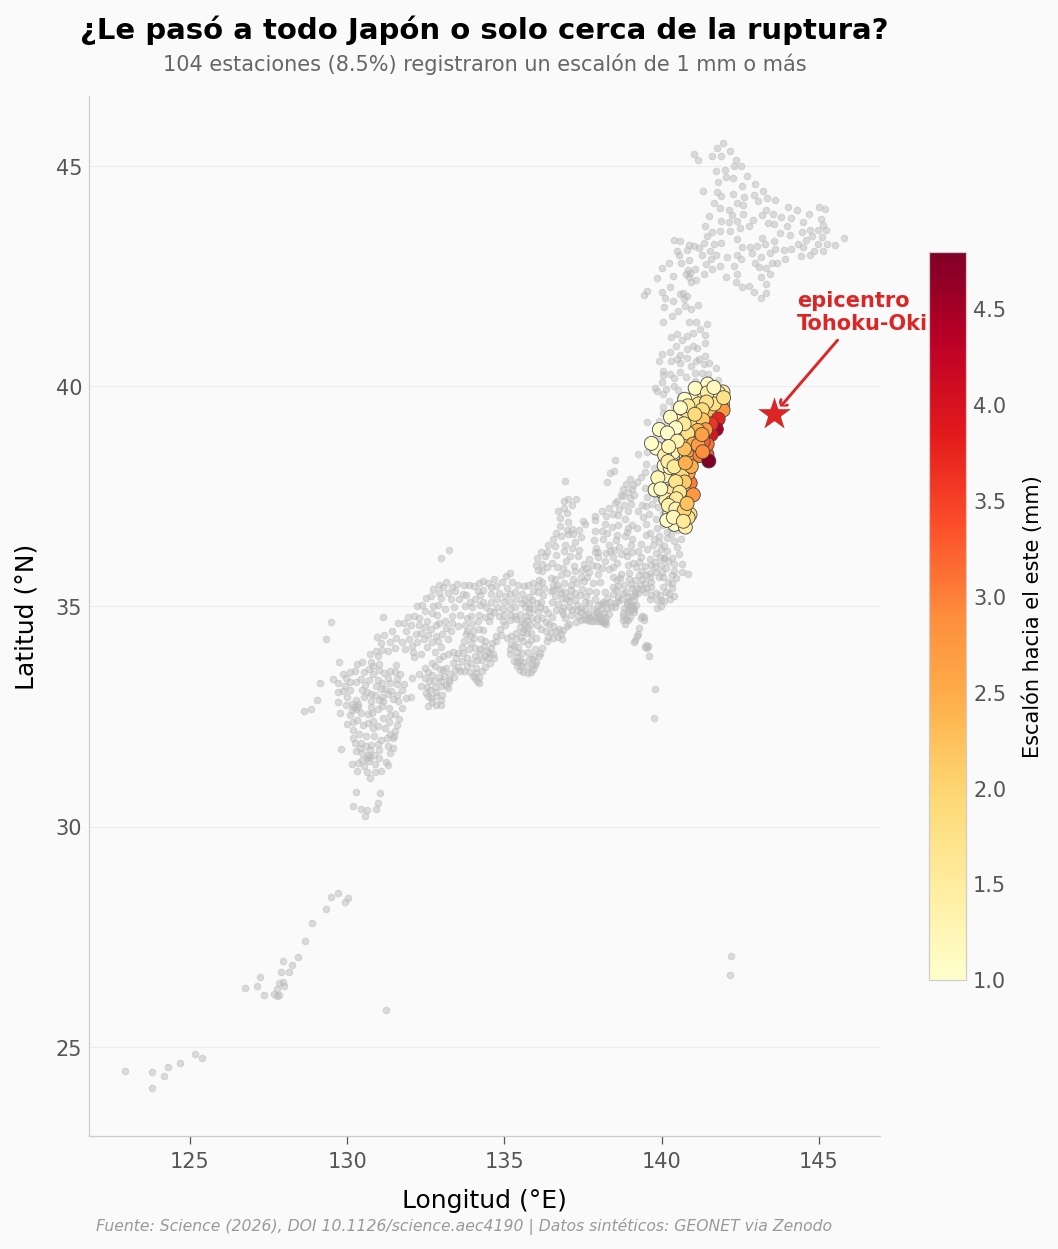

Estaciones con escalón >= 1 mm: 104 de 1221
Estaciones con escalón >= 3 mm: 9


In [3]:
fig, ax = plt.subplots(figsize=(8.5, 9))

# Estaciones sin señal apreciable, de fondo
sin = estaciones[estaciones.step_mm < UMBRAL_SENAL]
ax.scatter(sin.lon, sin.lat, color=COLOR_CONTEXTO, s=10, alpha=0.5, zorder=3)

# Estaciones con escalón, coloreadas por magnitud
con = estaciones[estaciones.step_mm >= UMBRAL_SENAL]
sc = ax.scatter(con.lon, con.lat, c=con.step_mm, cmap='YlOrRd',
                s=45, edgecolors='#444444', linewidths=0.4, zorder=5, vmin=1)
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label('Escalón hacia el este (mm)', fontsize=10)

# Epicentro
ax.scatter(143.57, 39.36, marker='*', s=420, color=COLOR_ALERTA,
           edgecolors='white', linewidths=1.2, zorder=7)
ax.annotate('epicentro\nTohoku-Oki', xy=(143.57, 39.36), xytext=(144.3, 41.3),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.4))

ax.set_title('¿Le pasó a todo Japón o solo cerca de la ruptura?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.025, f'{len(con)} estaciones ({pct_senal:.1f}%) registraron un escalón de 1 mm o más',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Longitud (°E)')
ax.set_ylabel('Latitud (°N)')

fig.text(0.13, 0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mapa_japon.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Estaciones con escalón >= 1 mm: {len(con)} de {n_total}")
print(f"Estaciones con escalón >= 3 mm: {int((estaciones.step_mm >= 3).sum())}")

El mapa cuenta dos cosas a la vez: el escalón apareció por todo el país —de Hokkaido a Okinawa hay más de 2.000 km—, pero los saltos grandes se apiñan cerca del epicentro. Pongamos esa intuición a prueba: ¿cuánto se diluye el escalón a medida que nos alejamos de la ruptura?

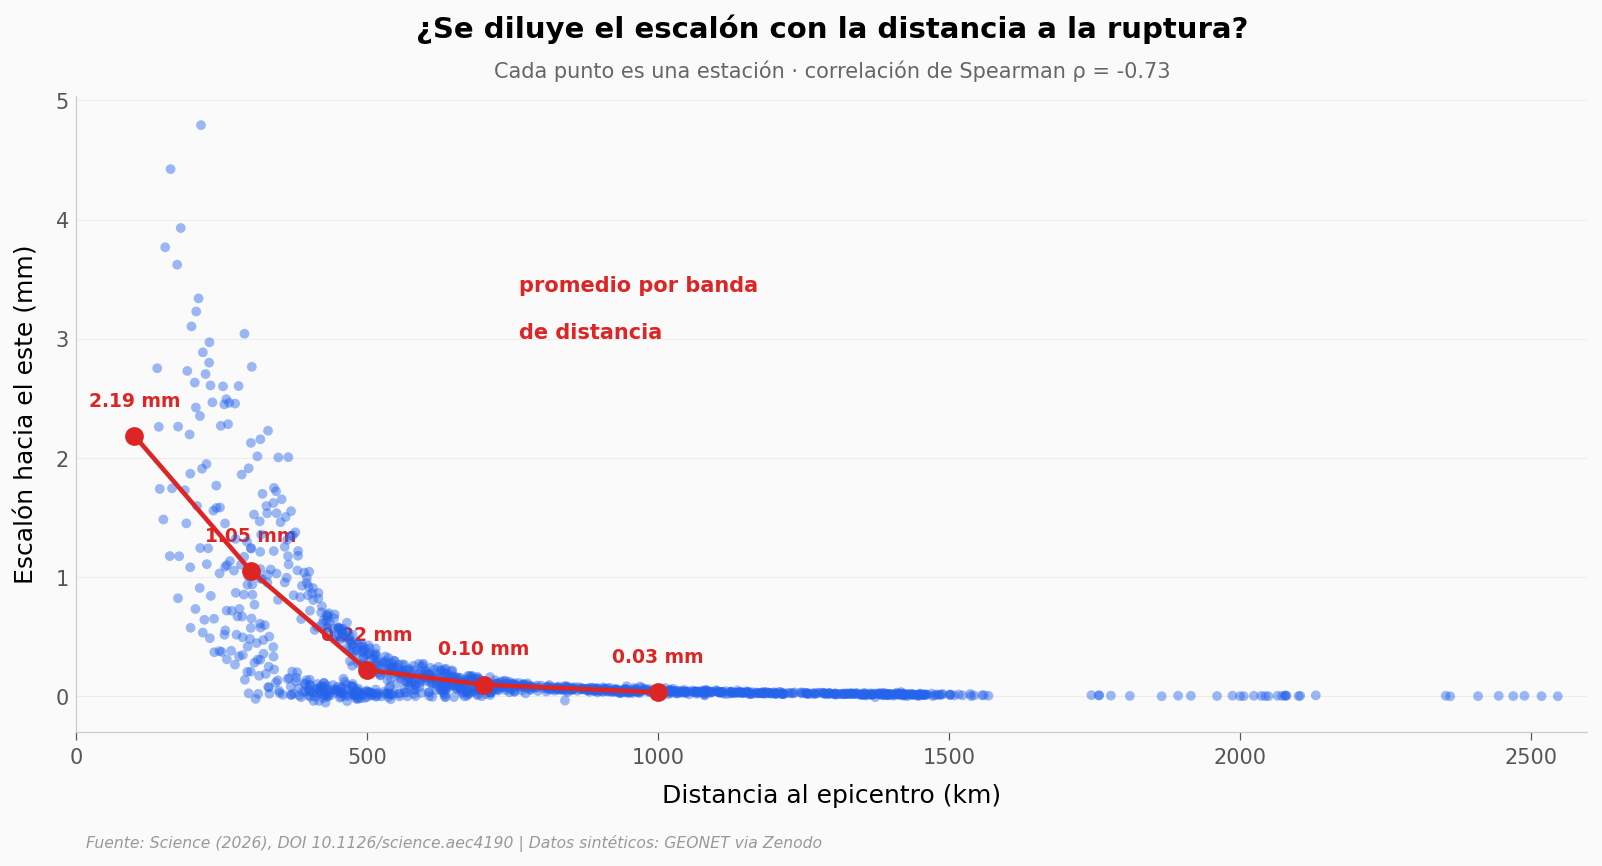

Spearman rho = -0.733 (p = 5.2e-206) — usamos Spearman porque la distribución está muy sesgada
Escalón promedio por banda:
      <200 km : 2.19 mm  (n = 21)
   200-400 km : 1.05 mm  (n = 182)
   400-600 km : 0.22 mm  (n = 282)
   600-800 km : 0.10 mm  (n = 225)
      >800 km : 0.03 mm  (n = 511)


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.scatter(estaciones.dist_km, estaciones.step_mm, color=COLOR_DATOS,
           s=22, alpha=0.45, edgecolors='none', zorder=4)

# Promedio por banda de distancia (del CSV agregado)
centros = {'<200': 100, '200-400': 300, '400-600': 500, '600-800': 700, '>800': 1000}
bx = [centros[d] for d in bandas.dband]
ax.plot(bx, bandas['mean'], color=COLOR_ALERTA, linewidth=2.2, marker='o',
        markersize=8, zorder=6)
for x, y, n in zip(bx, bandas['mean'], bandas['count']):
    ax.annotate(f'{y:.2f} mm', xy=(x, y), xytext=(x, y + 0.25),
                fontsize=9, color=COLOR_ALERTA, ha='center', fontweight='bold')

ax.text(760, 3.4, 'promedio por banda', fontsize=10, color=COLOR_ALERTA, fontweight='bold')
ax.text(760, 3.0, 'de distancia', fontsize=10, color=COLOR_ALERTA, fontweight='bold')

# Spearman porque la distribución está muy sesgada (no-normal)
rho, p = stats.spearmanr(estaciones.dist_km, estaciones.step_mm)

ax.set_title('¿Se diluye el escalón con la distancia a la ruptura?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Cada punto es una estación · correlación de Spearman ρ = {rho:.2f}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Distancia al epicentro (km)')
ax.set_ylabel('Escalón hacia el este (mm)')
ax.set_xlim(0, estaciones.dist_km.max() * 1.02)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distancia_decay.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Spearman rho = {rho:.3f} (p = {p:.1e}) — usamos Spearman porque la distribución está muy sesgada")
print("Escalón promedio por banda:")
for _, r in bandas.iterrows():
    print(f"  {r.dband:>8} km : {r['mean']:.2f} mm  (n = {int(r['count'])})")

Hay un detalle que vuelve esto raro de verdad. Ese escalón no fue apareciendo poco a poco de cerca a lejos, como las ondas normales que se propagan desde el epicentro. En las estaciones donde se puede medir el momento del salto, ocurrió con una mediana de **110 segundos** y un rango estrecho (entre 92 y 128 s): casi todo Japón se corrió **casi al mismo tiempo**. Esa simultaneidad encaja con la llegada de la ScS, que baja al núcleo y vuelve a emerger por todo el archipiélago a la vez.

Y una última pregunta cuantitativa: con casi todas las estaciones moviéndose poquísimo, ¿qué tan excepcional es el escalón de la estación más golpeada?

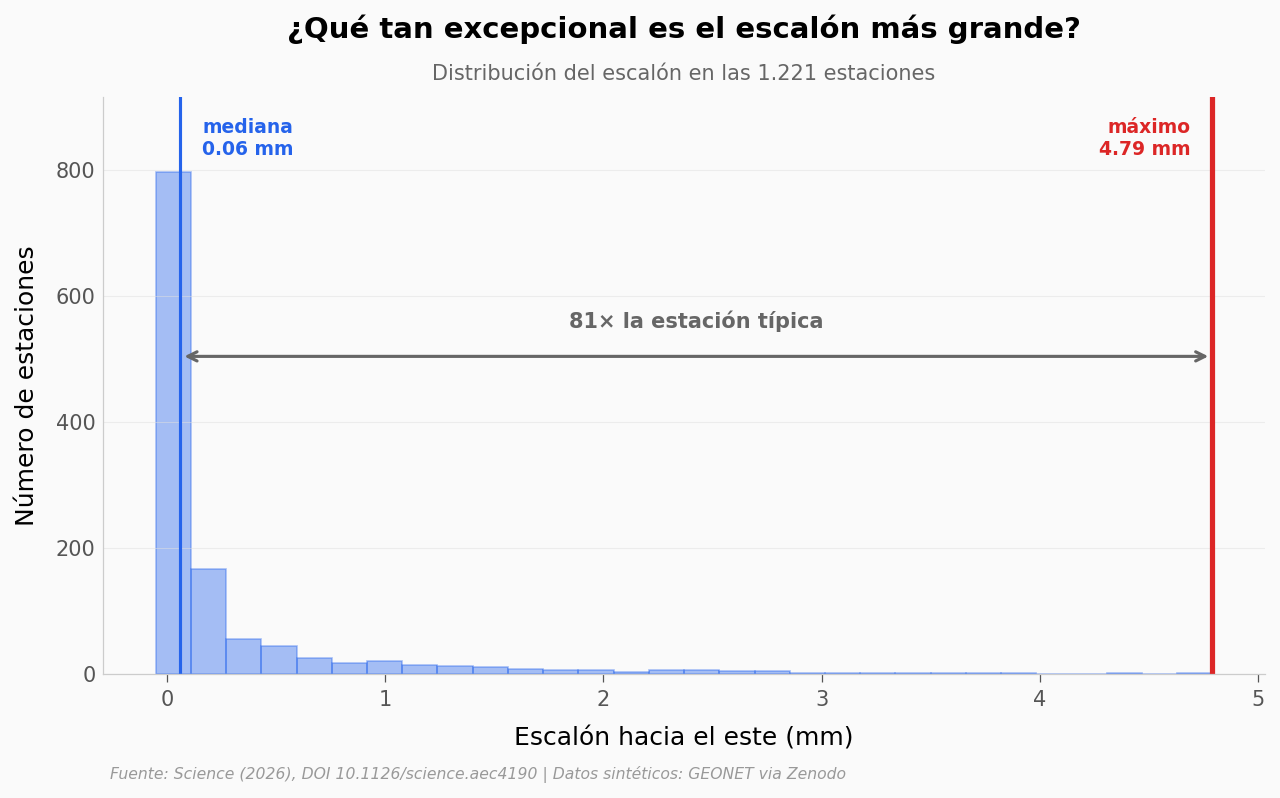

Asimetría (skew): 3.54 — cola larga hacia los valores grandes
La mayoría de estaciones casi no se movió; unas pocas, cerca de la ruptura, dieron el salto grande


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

data = estaciones.step_mm.values
n, bins, patches = ax.hist(data, bins=30, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

mediana = np.median(data)
maximo = data.max()
ax.axvline(x=mediana, color=COLOR_DATOS, linewidth=1.5)
ax.axvline(x=maximo, color=COLOR_ALERTA, linewidth=2.5)
ax.annotate('', xy=(maximo, y_max * 0.55), xytext=(mediana, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((mediana + maximo) / 2, y_max * 0.60,
        f'{maximo / mediana:.0f}× la estación típica',
        fontsize=10, color='#666666', ha='center', fontweight='bold')
ax.text(mediana + 0.1, y_max * 0.9, f'mediana\n{mediana:.2f} mm',
        fontsize=9, color=COLOR_DATOS, fontweight='bold')
ax.text(maximo - 0.1, y_max * 0.9, f'máximo\n{maximo:.2f} mm',
        fontsize=9, color=COLOR_ALERTA, fontweight='bold', ha='right')

ax.set_title('¿Qué tan excepcional es el escalón más grande?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución del escalón en las 1.221 estaciones',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Escalón hacia el este (mm)')
ax.set_ylabel('Número de estaciones')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Asimetría (skew): {stats.skew(data):.2f} — cola larga hacia los valores grandes")
print(f"La mayoría de estaciones casi no se movió; unas pocas, cerca de la ruptura, dieron el salto grande")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Tras la onda ScS, el suelo registró un escalón permanente hacia el este | ✅ | El dato observado real llega a 5–6 mm; la serie **sintética** que abrimos aquí alcanza 4,79 mm en la estación 0550. El modelo se queda algo por debajo del observado. |
| El escalón apareció en todo Japón, no solo cerca de la ruptura | ✅ | 104 estaciones (8,5 %) con escalón ≥ 1 mm, repartidas de Hokkaido a Okinawa (>2.000 km). |
| El escalón se diluye con la distancia a la ruptura | ✅ | Spearman ρ = −0,73. Promedio < 200 km: 2,19 mm; > 800 km: 0,03 mm. (Usamos Spearman, no Pearson, porque la distribución está muy sesgada.) |
| El salto ocurrió casi simultáneamente en todo el país | ✅ | Mediana 110 s, rango 10–90 % de 92 a 128 s en las 306 estaciones donde se puede medir el momento del salto. |
| La onda ScS *disparó* deslizamiento en las fallas megathrust | ⚠️ | Es la **interpretación** del paper ("likely"), no una medición. Estudio observacional: el escalón coincide en tiempo con la llegada de la ScS; todo apunta a ese mecanismo, pero no se manipuló nada para probarlo. |
| Esto es una fuente de peligro sísmico que podría reactivar la zona | ⚠️ | El paper lo plantea como posibilidad ("potentially"), no como riesgo establecido. |

> **Limitaciones:** las series que exploramos son **sintéticas** (salida de un modelo), no las observaciones GNSS crudas; reproducen el escalón pero subestiman un poco su tamaño. El "momento del salto" solo se mide bien en las 306 estaciones con señal clara (|escalón| > 0,2 mm). Y lo más importante: que la ScS *cause* el deslizamiento es una inferencia de un estudio observacional, no un experimento.

## Ahora tú

1. **¿Y si bajas el umbral de "señal"?** Cambia `UMBRAL_SENAL = 1.0` a `0.5` en la celda de configuración y vuelve a correr el mapa. ¿Cuántas estaciones más aparecen? ¿Dónde están?

2. **¿Cómo se ve otra estación?** El dataset trae la serie completa solo de la 0550, pero `step_por_estacion.csv` tiene el escalón de las 1.221. Ordénalas por `step_mm` y mira qué estaciones siguen en la cola: `estaciones.sort_values('step_mm', ascending=False).head(15)`.

3. **¿La sacudida predice el escalón?** Cada estación tiene `p2p_mm` (cuánto sacudió la onda) y `step_mm` (cuánto quedó corrido). ¿Van de la mano? Prueba un scatter de una contra otra.

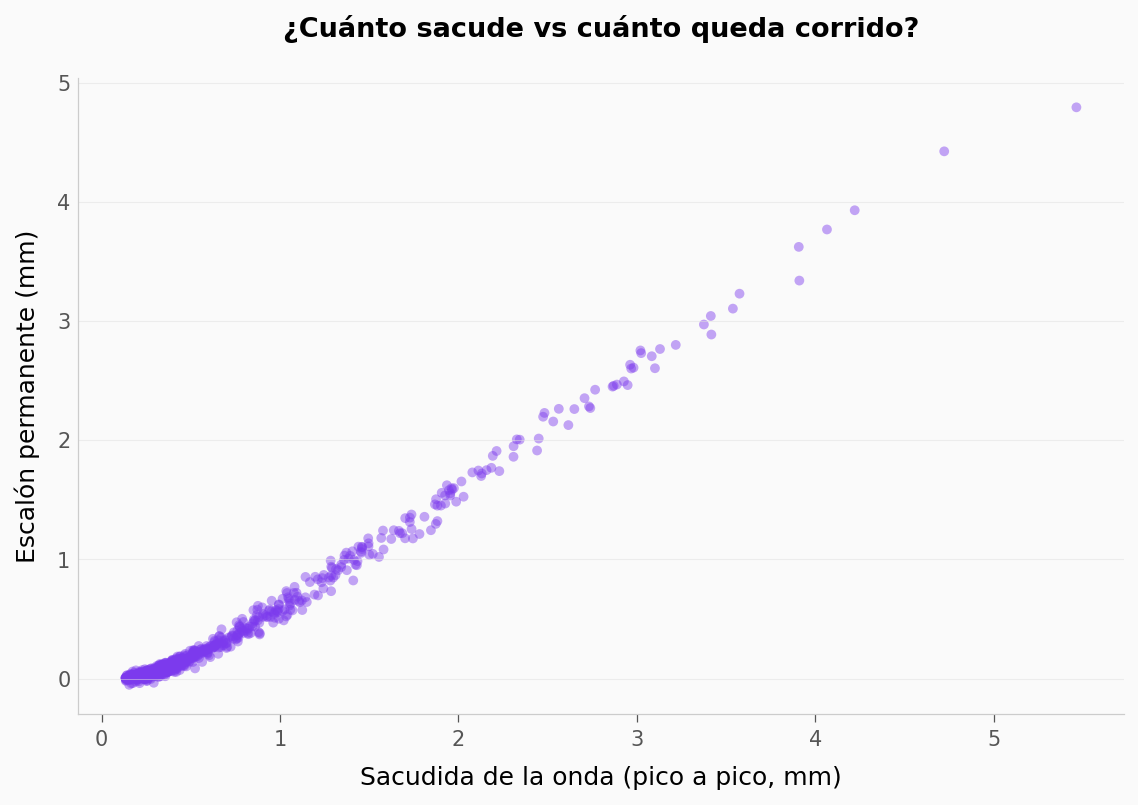

Spearman entre sacudida y escalón: rho = 0.96
Pista: prueba a colorear los puntos por dist_km y mira si la relación cambia con la distancia.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿La fuerza de la sacudida (p2p) predice el tamaño del escalón permanente?
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.scatter(estaciones.p2p_mm, estaciones.step_mm, color='#7C3AED',
           s=22, alpha=0.45, edgecolors='none')
rho_pe, _ = stats.spearmanr(estaciones.p2p_mm, estaciones.step_mm)

ax.set_title('¿Cuánto sacude vs cuánto queda corrido?',
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Sacudida de la onda (pico a pico, mm)')
ax.set_ylabel('Escalón permanente (mm)')
plt.show()

print(f"Spearman entre sacudida y escalón: rho = {rho_pe:.2f}")
print("Pista: prueba a colorear los puntos por dist_km y mira si la relación cambia con la distancia.")

## Créditos

- **Paper:** *ScS-triggered slip on megathrust interfaces after the 2011 Mw 9.0 Tohoku-Oki earthquake.* Science (2026). DOI: [10.1126/science.aec4190](https://doi.org/10.1126/science.aec4190)
- **Datos:** series sintéticas de desplazamiento en estaciones GEONET, [Zenodo](https://doi.org/10.5281/zenodo.19597316). Observaciones reales 1-Hz PPP de referencia: [PANGAEA](https://doi.org/10.1594/PANGAEA.914110).
- **Licencia datos:** según los términos de Zenodo / PANGAEA.
- **Repo:** [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)

## Fuentes

**Paper**: [ScS-triggered slip on megathrust interfaces after the 2011 Mw 9.0 Tohoku-Oki earthquake](https://doi.org/10.1126/science.aec4190)  
*Science, 2026-06-18*

**Dataset canónico**: [Synthetic displacement timeseries at GEONET GNSS stations for the 2011 Mw9.0 Tohoku-Oki Earthquake](https://doi.org/10.5281/zenodo.19597316)  
*series sintéticas de desplazamiento en estaciones GEONET*

**Referencias citadas**: [1-Hz PPP displacements at GEONET stations during the 2011 Tohoku Mw9.0 earthquake (Shu & Xu)](https://doi.org/10.1594/PANGAEA.914110) — observaciones 1-Hz PPP reales

*17 afirmaciones del notebook verificadas contra estas fuentes*